# Analiza dostępnych modeli

## Anonymizer

W celu anonimizacji nagrań z kamer wykorzystamy uczenie maszynowe aby zamazywać twarze oraz tablice rejestracyjne na filmach. Problem ten dzieli się na kilka części:
- Wykrywanie twarzy
- Zamazywanie twarzy
- Wykrywanie tablic rejestracyjnych
- Zamazywanie tablic

W celu zamazywania wykrytych obszarów możemy przykładowo wykorzystać filtr Gaussa. Większe wyzwanie stanowi wykrywanie obszarów

### Wykrywanie twarzy

Do detekcji twarzy na filmach możemy wykorzystać:
- [Sieci YOLO](https://github.com/YapaLab/yolo-face)

#### Sieci YOLO
Dostępne są sieci YOLO wytrenowane w celu detekcji twarzy na obrazie. Są one szybkie, dokładne i działają na obrazach z kamer przemysłowych. Ich minusem jest to że wykrywają one domyślnie `bounding box` czyli prostokąt w którym mieści się wykryty obiekt. Może to sprawiać problemy podczas zamazywania twarzy, z uwagi na fakt że twarze nie są kwadratowe. Aby dokładnie wybrać obszar zamazywania można dodatkowo wykorzystać model segmentacji semantycznej twarzy.

In [2]:
# funkcje pomocnicze
import cv2
import matplotlib.pyplot as plt

def yolo_image_example(model, image, title):
    results = model.predict(image, verbose=False)
    plt.figure()
    plt.axis('off')
    plt.title(title)
    plt.imshow(results[0].plot());

def yolo_video_example(model, input, output):
    cap = cv2.VideoCapture(input)
    if not cap.isOpened():
        print('Nie znaleziono filmu')
    else:
        width = int(cap.get(3))
        height = int(cap.get(4))
        fps = cap.get(cv2.CAP_PROP_FPS)
        fourcc = cv2.VideoWriter_fourcc(*'XVID')

        out = cv2.VideoWriter(output, fourcc, fps, (width, height))
        while True:
            success, frame = cap.read()
            if success:
                results = model.track(frame, verbose=False)
                annotated_frame = results[0].plot()
                out.write(annotated_frame)
            else:
                print('Przetworzono film')
                break
    cap.release()
    out.release()

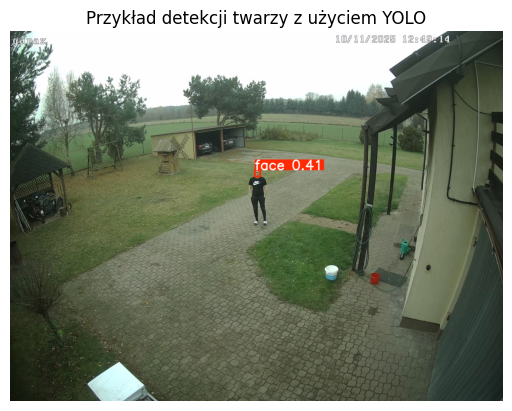

In [ ]:
from ultralytics import YOLO

image_path = 'examples/image1.jpg'
image = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
model = YOLO('anonymizer/models/yolov12l-face.pt')

yolo_image_example(model, image, 'Przykład detekcji twarzy z użyciem YOLO')

In [ ]:
from ultralytics import YOLO
input_video = 'examples/video1.mp4'
output_video = 'anonymizer/face_examples/video1.avi' # przykładowy film

model = YOLO('anonymizer/models/yolov12l-face.pt')

yolo_video_example(model, input_video, output_video)

Przetworzono film


### Wykrywanie tablic rejestracyjnych

W celu wykrywania tablic rejestracyjnych można wykorzystać:
- Sieci YOLO (modele detekcji obrazów)
- Klasyczna analiza obrazów

Dostępne dane treningowe:
- https://universe.roboflow.com/roboflow-universe-projects/license-plate-recognition-rxg4e

#### Sieci YOLO
W celu użycia sieci YOLO należy wybrać model detekcji obrazów który następnie wytrenujemy na wybranych danych. Wybrałem model YOLO12s który wytrenowałem na danych podanych wyżej. Przykładowe obrazy i bounding boxy z datasetu

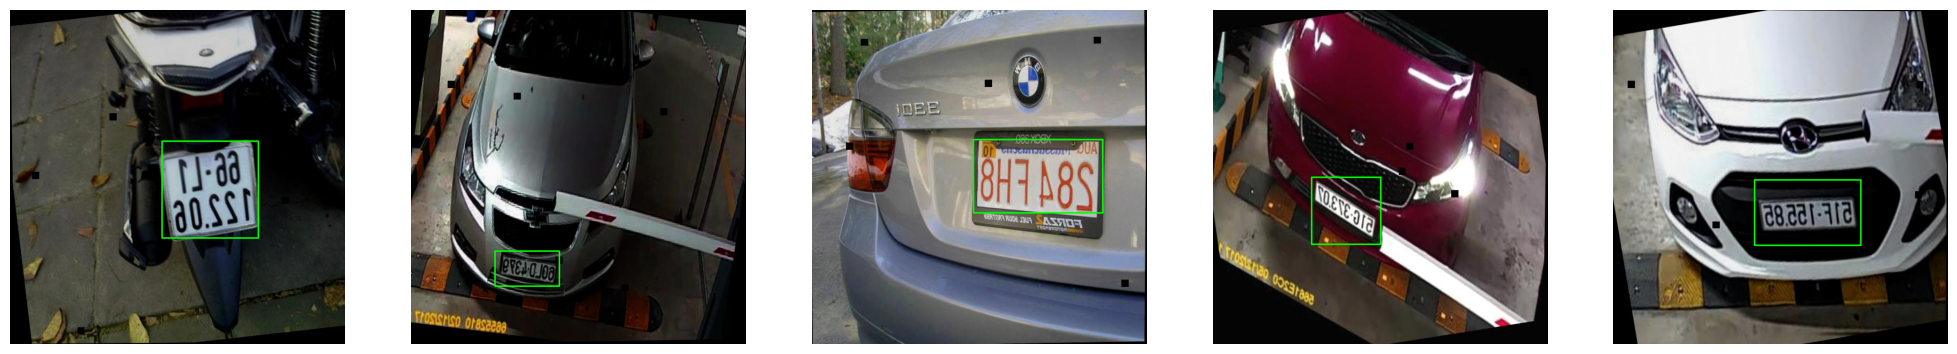

In [55]:
from ultralytics import YOLO
import os
import cv2
import random
import matplotlib.pyplot as plt

LICENSE_PLATE_DATA_DIR = 'anonymizer/license_plate_data'
n_examples = 5

image_dir = f'{LICENSE_PLATE_DATA_DIR}/train/images'
label_dir = f'{LICENSE_PLATE_DATA_DIR}/train/labels'

all_images = os.listdir(image_dir)

random.seed(42)
selected_images = random.sample(all_images, n_examples)

images = []
labels = []

for img_name in selected_images:
    img_path = f"{image_dir}/{img_name}"
    label_name = img_name.rsplit('.', 1)[0] + '.txt'
    label_path = f"{label_dir}/{label_name}"

    images.append(cv2.imread(img_path))

    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            labels.append(f.read().strip().splitlines())
    else:
        labels.append([])

def draw_yolo_boxes(image, label_lines):
    h, w = image.shape[:2]

    for line in label_lines:
        cls, x_c, y_c, bw, bh = map(float, line.split())

        x1 = int((x_c - bw / 2) * w)
        y1 = int((y_c - bh / 2) * h)
        x2 = int((x_c + bw / 2) * w)
        y2 = int((y_c + bh / 2) * h)

        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
    return image

plt.figure(figsize=(n_examples * 5, 5))

for i in range(n_examples):
    img = images[i].copy()
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = draw_yolo_boxes(img, labels[i])

    plt.subplot(1, n_examples, i + 1)
    plt.imshow(img)
    plt.axis('off')

plt.show()


In [ ]:
from multiprocessing import freeze_support

# !wget https://github.com/ultralytics/assets/releases/download/v8.3.0/yolo12s.pt 

if __name__ == '__main__':

    # Bez tego nie działa na windows
    freeze_support() 
    
    model = YOLO('anonymizer/models/yolo12s-plate.pt')
    
    results = model.train(data=f'{LICENSE_PLATE_DATA_DIR}/data.yaml', epochs=100)

## Detektor zachowań

Aby móc wykrywać zachowania ludzi przydatne może być określenie ich szkieletu kinematycznego. Określa on położenie wybranych punktów ciała. Umożliwia to przybliżenie pozycji w jakiej znajduje się człowiek. W tym celu możemy zastosować przykładowe modele:
- [Sieci YOLO](docs.ultralytics.com/tasks/pose/)

### Sieci YOLO
W internecie dostępne są wytrenowane sieci YOLO ukierunkowane na określanie pozycji człowieka. Jako baze wykorzystamy modele udostępnione przez *ultralytics*.

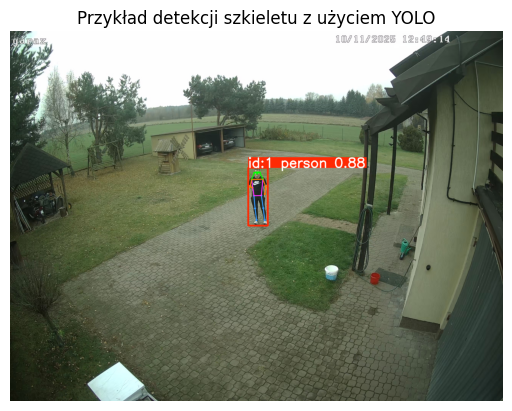

In [52]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

image_path = 'examples/image1.jpg'
image = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)

yolo_image_example(model, image, 'Przykład detekcji szkieletu z użyciem YOLO')

In [50]:
from ultralytics import YOLO
input_video1 = 'examples/video1.mp4'
output_video1 = 'behavior_detector/skeleton_examples/video1.avi'
input_video2 = 'examples/video2.mp4'
output_video2 = 'behavior_detector/skeleton_examples/video2.avi'

model = YOLO('behavior_detector/models/yolo11x-pose.pt')

yolo_video_example(model, input_video1, output_video1)
yolo_video_example(model, input_video2, output_video2)

Przetworzono film
Przetworzono film


In [3]:
from ultralytics import YOLO
input_video = 'video1.mp4'
output_video = 'video3.avi'

model = YOLO('behavior_detector/models/yolo11x-pose.pt')

yolo_video_example(model, input_video, output_video)

Przetworzono film
